# YZM2022: Data Mining - Homework 1
## Association Rule Mining and Sequential Pattern Analysis

## Libraries

In [1]:
# Veri manipülasyonu ve analizi için gerekli kütüphaneler
import pandas as pd
import numpy as np

# Grafik ve görselleştirme araçları
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Performans ölçümü ve sistem yönetimi modülleri
import warnings
import time
import tracemalloc
import re
import os
import csv
from itertools import combinations
from collections import defaultdict

# Association Rule Mining algoritmaları
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Notebook çıktılarını yönetme araçları
from IPython.display import Image, display

# Uyarı mesajlarını sessize alma
warnings.filterwarnings('ignore')

# Grafiklerin görsel standartlarını belirleme
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries and configurations loaded successfully.")

Libraries and configurations loaded successfully.


## Data Loading & Preprocessing

In [2]:
# CSV dosyasını yükle
CSV_PATH = 'data/dataset_son.csv'

df_raw = pd.read_csv(CSV_PATH)
df_raw.head(3)

,order_id,product_id,product_name,user_id,days_since_prior_order,add_to_cart_order
0,2,"33120, 28985, 9327, 45918, 30035, 17794, 40141...","Organic Egg Whites, Michigan Organic Kale, Gar...",202279,8.0,"1, 2, 3, 4, 5, 6, 7, 8, 9"
1,3,"33754, 24838, 17704, 21903, 17668, 46667, 1746...",Total 2% with Strawberry Lowfat Greek Strained...,205970,12.0,"1, 2, 3, 4, 5, 6, 7, 8"
2,4,"46842, 26434, 39758, 27761, 10054, 21351, 2259...","Plain Pre-Sliced Bagels, Honey/Lemon Cough Dro...",178520,7.0,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13"


In [3]:
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

Raw data shape: (3214874, 6)
Columns: ['order_id', 'product_id', 'product_name', 'user_id', 'days_since_prior_order', 'add_to_cart_order']


In [4]:
processed_rows = []

for row in df_raw.itertuples(index=False):
    # Birleşik kayıtları temizleyerek listeye ayır
    pids = [p.strip() for p in str(row.product_id).replace('"', '').split(',') if p.strip()]
    n = len(pids)

    # Ürün isimlerini ID sayısı kadar parçala
    # İsimdeki fazla virgüllerin hatalı eşleşmeye yol açmaması için n-1 sınırı kullan
    pnames = [p.strip() for p in str(row.product_name).split(', ', maxsplit=n-1)]

    # Veri kaybını önlemek için ismi bulunmayan ürünleri ID ile adlandır
    if len(pnames) < n:
        pnames.extend([f"product_{pids[i]}" for i in range(len(pnames), n)])

    # Her ürünü meta verisiyle ayrı bir Transaction satırı haline getir
    for pid, pname in zip(pids, pnames):
        processed_rows.append({
            'order_id': row.order_id,
            'user_id': row.user_id,
            'product_id': pid,
            'product_name': pname,
            'days_since_prior_order': row.days_since_prior_order
        })

# Analiz hızını artırmak için listeyi DataFrame formatına sok
df_final = pd.DataFrame(processed_rows)
print(f"Transformation complete. Total rows: {len(df_final):,}")

# Analiz çıktılarını anlamlandırmak için ID -> Name Mapping kur
id_to_name = dict(zip(df_final['product_id'], df_final['product_name']))

# Aynı isme sahip farklı ID'leri gruplamak için Reverse Mapping oluştur
name_to_ids = defaultdict(set)
for pid, name in id_to_name.items():
    name_to_ids[name].add(pid)

print(f"Unique product IDs found:   {len(id_to_name):,}")
print(f"Unique product names found: {len(name_to_ids):,}")

Transformation complete. Total rows: 32,434,489
Unique product IDs found:   49,677
Unique product names found: 42,107


## PART 1
## Exploratory Data Analysis (EDA)

### 1.1. Basket Size Analysis

In [5]:
# Her Transaction içindeki ürün miktarını belirle
basket_sizes = df_final.groupby('order_id')['product_id'].count()

print("Basket Size Analysis")
print(f"Mean basket size:               {basket_sizes.mean():.2f}")
print(f"Median basket size:             {basket_sizes.median():.2f}")
print(f"Standard deviation:             {basket_sizes.std():.2f}")
print(f"Minimum basket size:            {basket_sizes.min()}")
print(f"Maximum basket size:            {basket_sizes.max()}")

print("\nDistribution Percentiles")
print(basket_sizes.quantile([0.25, 0.5, 0.75, 0.90, 0.95]))

Basket Size Analysis
Mean basket size:               10.09
Median basket size:             8.00
Standard deviation:             7.53
Minimum basket size:            1
Maximum basket size:            145

Distribution Percentiles
0.25     5.0
0.50     8.0
0.75    14.0
0.90    20.0
0.95    25.0
Name: product_id, dtype: float64


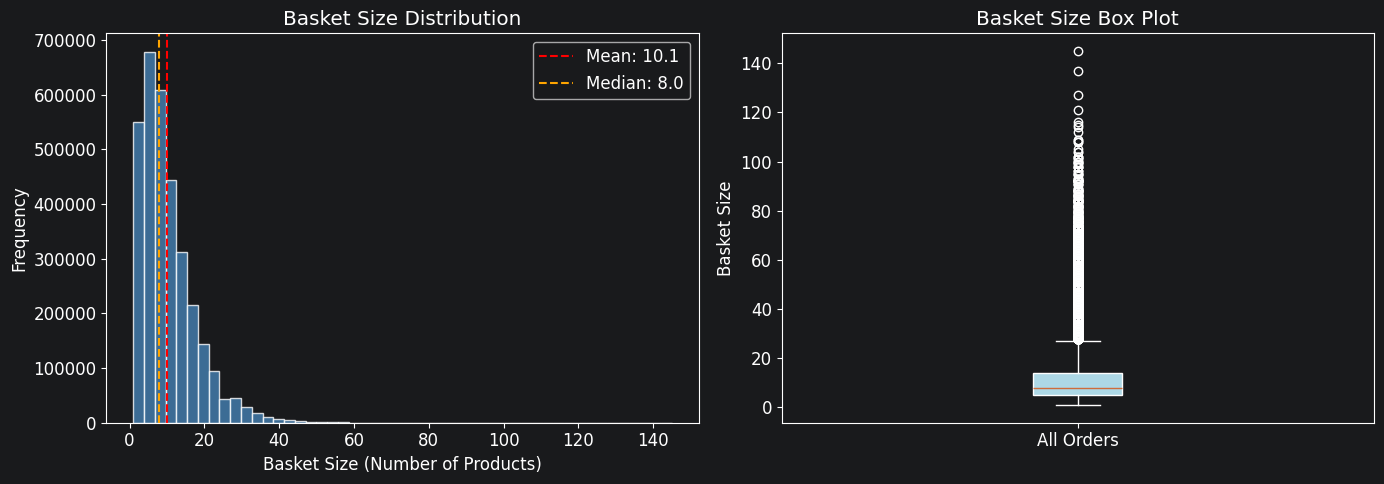

In [6]:
# Basket size histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(basket_sizes, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(basket_sizes.mean(), color='red', linestyle='--', label=f'Mean: {basket_sizes.mean():.1f}')
axes[0].axvline(basket_sizes.median(), color='orange', linestyle='--', label=f'Median: {basket_sizes.median():.1f}')
axes[0].set_title('Basket Size Distribution')
axes[0].set_xlabel('Basket Size (Number of Products)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(basket_sizes, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Basket Size Box Plot')
axes[1].set_ylabel('Basket Size')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['All Orders'])

plt.tight_layout()
plt.savefig('plots/basket_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2. Customer Purchase Frequency

In [7]:
# User başına sipariş sayısı
user_freq = df_final.groupby('user_id')['order_id'].nunique()

print("--- Customer Purchase Frequency ---")
print(f"Total number of users:           {user_freq.shape[0]}")
print(f"Mean orders per customer:        {user_freq.mean():.2f}")
print(f"Median orders per customer:      {user_freq.median():.2f}")

# Classification: Regular vs. Infrequent, sadık müşteriler için 0.75 threshold
threshold = user_freq.quantile(0.75)
regular = (user_freq >= threshold).sum()
infrequent = (user_freq < threshold).sum()

print(f"\nThreshold 75th percentile {threshold:.0f} orders")
print(f"Regular customers (>= threshold)  {regular} ({100*regular/len(user_freq):.1f}%)")
print(f"Infrequent customers (< threshold) {infrequent} ({100*infrequent/len(user_freq):.1f}%)")

--- Customer Purchase Frequency ---
Total number of users:           206209
Mean orders per customer:        15.59
Median orders per customer:      9.00

Threshold 75th percentile 19 orders
Regular customers (>= threshold)  53931 (26.2%)
Infrequent customers (< threshold) 152278 (73.8%)


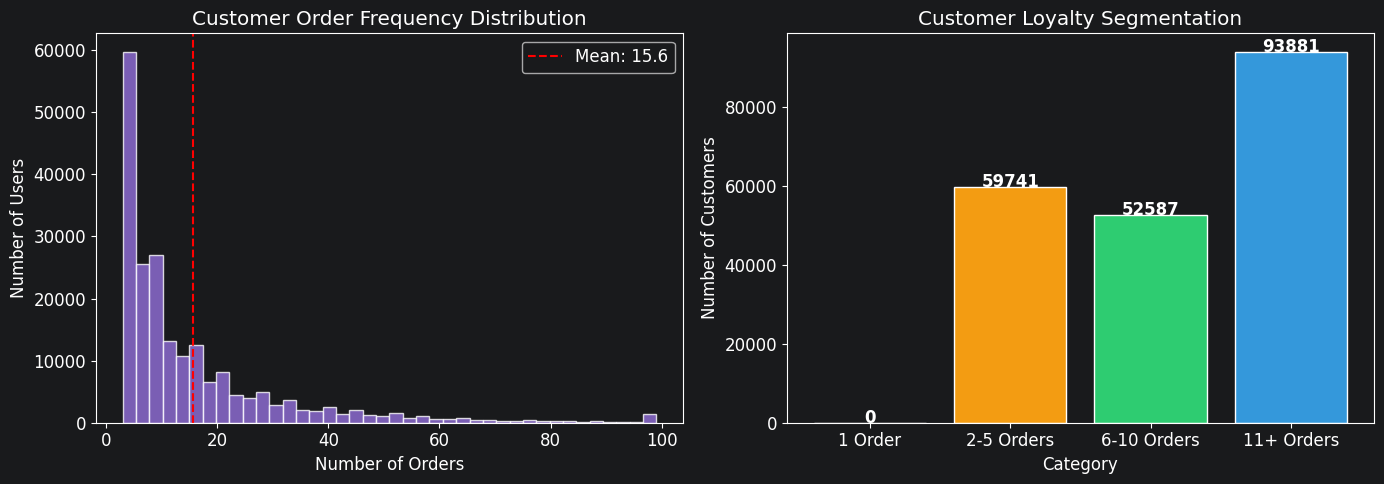

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(user_freq, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0].set_title('Customer Order Frequency Distribution')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(user_freq.mean(), color='red', linestyle='--', label=f'Mean: {user_freq.mean():.1f}')
axes[0].legend()

# Categorical bar chart for segmentation
category_labels = ['1 Order', '2-5 Orders', '6-10 Orders', '11+ Orders']
category_counts = [
    (user_freq == 1).sum(),
    ((user_freq >= 2) & (user_freq <= 5)).sum(),
    ((user_freq >= 6) & (user_freq <= 10)).sum(),
    (user_freq > 10).sum()
]
axes[1].bar(category_labels, category_counts, color=['#e74c3c','#f39c12','#2ecc71','#3498db'], edgecolor='white')
axes[1].set_title('Customer Loyalty Segmentation')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Customers')

# Add labels on top of bars
for i, v in enumerate(category_counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/customer_activity.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3. Pareto Analysis (80/20 Rule)

In [9]:
# Her ürünün toplam satış miktarını belirle
product_freq = df_final['product_name'].value_counts()
total_sales = product_freq.sum()

# Pareto Analizi için kümülatif satış yüzdesini hesapla
cumulative_pct = product_freq.cumsum() / total_sales * 100

# Satışların yüzde 80'ini oluşturan kritik ürün sayısını bul
n_80 = (cumulative_pct <= 80).sum()
pct_products_80 = 100 * n_80 / len(product_freq)

print("Pareto Analysis (80/20 Rule)")
print(f"Total unique products:                {len(product_freq)}")
print(f"Total sales (unit count):             {total_sales}")
print(f"\nNumber of products accounting for 80% of sales: {n_80}")
print(f"This corresponds to only {pct_products_80:.1f}% of all products.")

# 80/20 kuralının veri seti üzerindeki geçerliliğini kontrol et
status = "VERIFIED" if pct_products_80 <= 25 else "PARTIALLY VALID"
print(f"\n-> 80/20 rule {status} {pct_products_80:.1f}% of products account for 80% of total sales.")

Pareto Analysis (80/20 Rule)
Total unique products:                688592
Total sales (unit count):             32434489

Number of products accounting for 80% of sales: 5104
This corresponds to only 0.7% of all products.

-> 80/20 rule VERIFIED 0.7% of products account for 80% of total sales.


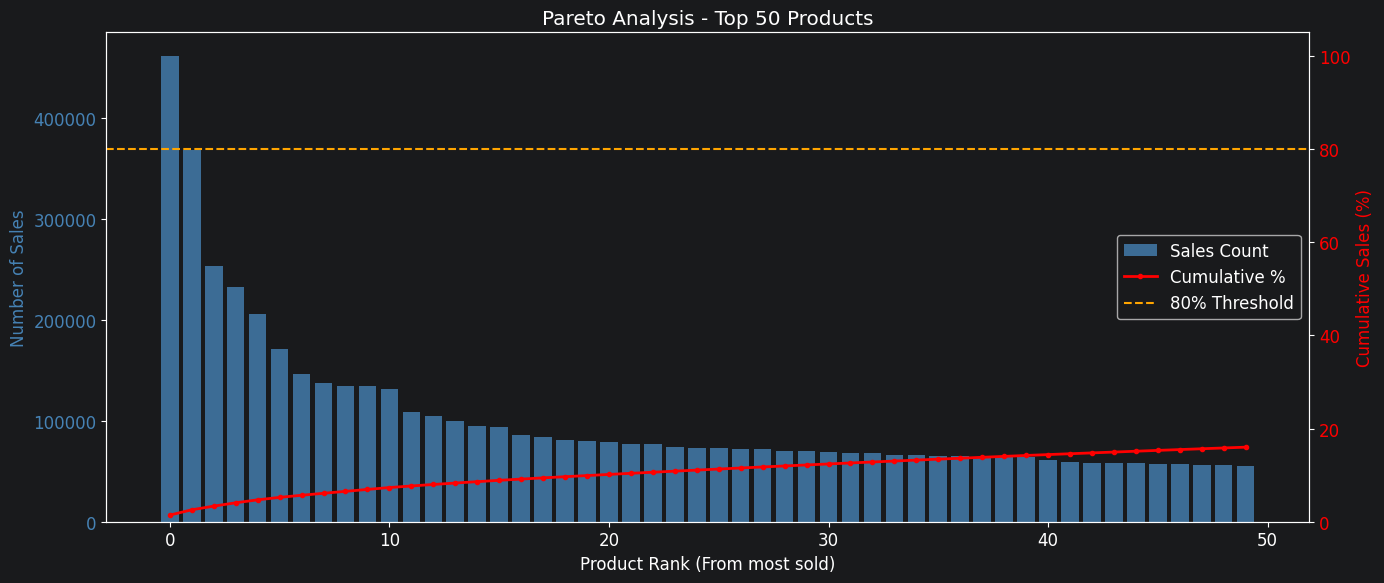

In [10]:
# Pareto Chart Visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

# Görsel netlik sağlamak için sadece en çok satılan ilk 50 ürünü seç
top_n = min(50, len(product_freq))
top_products = product_freq.head(top_n)
cum_pct_top = cumulative_pct.head(top_n)

# Satış adetlerini bar chart olarak çiz
ax1.bar(range(top_n), top_products.values, color='steelblue', alpha=0.8, label='Sales Count')
ax1.set_xlabel('Product Rank (From most sold)')
ax1.set_ylabel('Number of Sales', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# İkinci bir y ekseni oluşturarak kümülatif satış yüzdesini ekle
ax2 = ax1.twinx()
ax2.plot(range(top_n), cum_pct_top.values, color='red', marker='.', linewidth=2, label='Cumulative %')

# Pareto ilkesini doğrulamak için %80 seviyesine eşik çizgisi çek
ax2.axhline(80, color='orange', linestyle='--', linewidth=1.5, label='80% Threshold')
ax2.set_ylabel('Cumulative Sales (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

# Grafik başlığını ve lejantı tanımla
plt.title(f'Pareto Analysis - Top {top_n} Products')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
# Hazırlanan grafiği çıktı klasörüne kaydet
plt.savefig('plots/pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4. Visualization

##### 1.4.1 Bar chart of product frequencies (descending order)

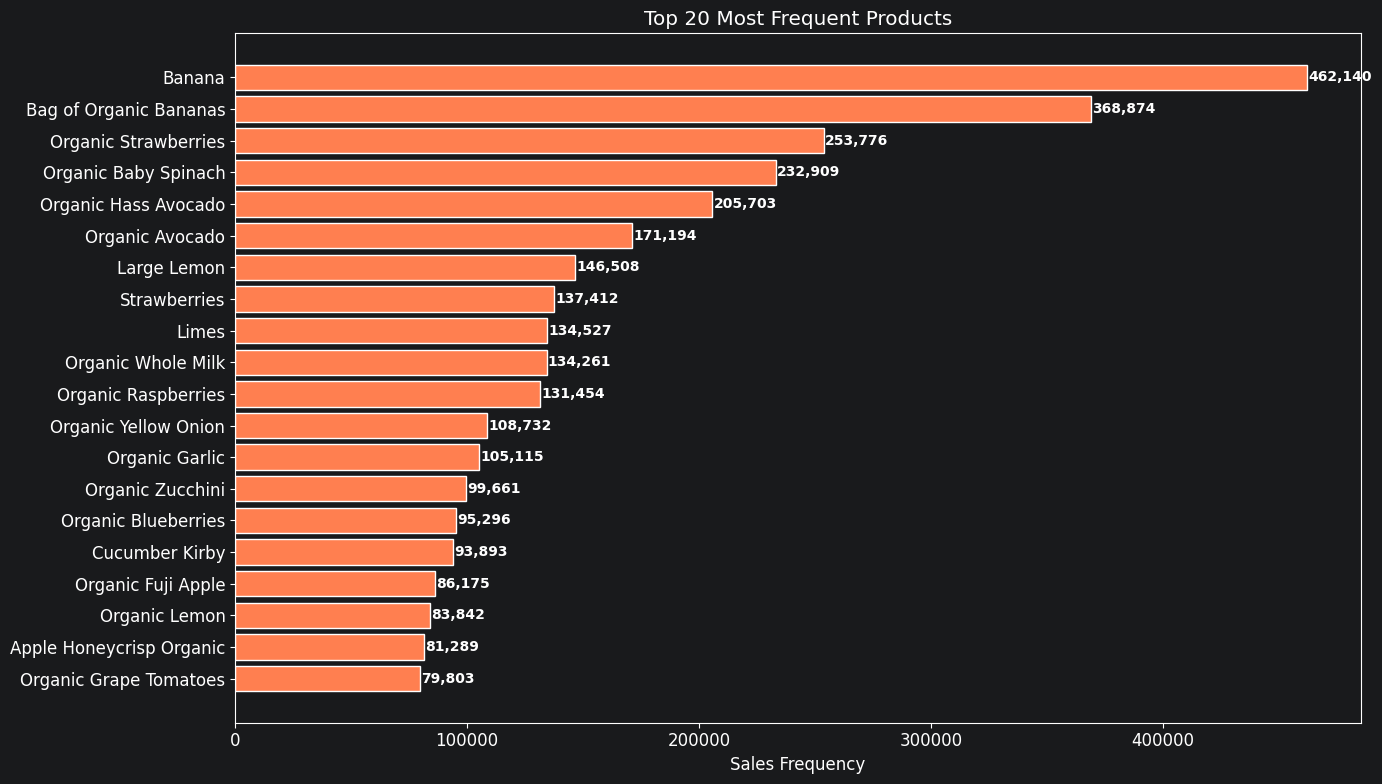

In [11]:
top20 = product_freq.head(20)

plt.figure(figsize=(14, 8))
# Reverse order for horizontal chart so the #1 product is at the top
bars = plt.barh(top20.index[::-1], top20.values[::-1], color='coral', edgecolor='white')

plt.xlabel('Sales Frequency')
plt.title('Top 20 Most Frequent Products')

# Adding value labels to the end of each bar
for bar, val in zip(bars, top20.values[::-1]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/top20_products.png', dpi=150, bbox_inches='tight')
plt.show()

Bu grafik, veri setindeki ürün popülerliğini göstermektedir. Satışların büyük bir kısmının "Banana", "Organic Strawberries" gibi taze ürünler tarafından domine edildiği görülmektedir. Bu durum, Association Rule Mining yaparken bu ürünlerin çok yüksek "support" değerlerine sahip olacağını ve birçok kuralın merkezinde yer alacağını kanıtlar

##### 1.4.2 Basket size distribution

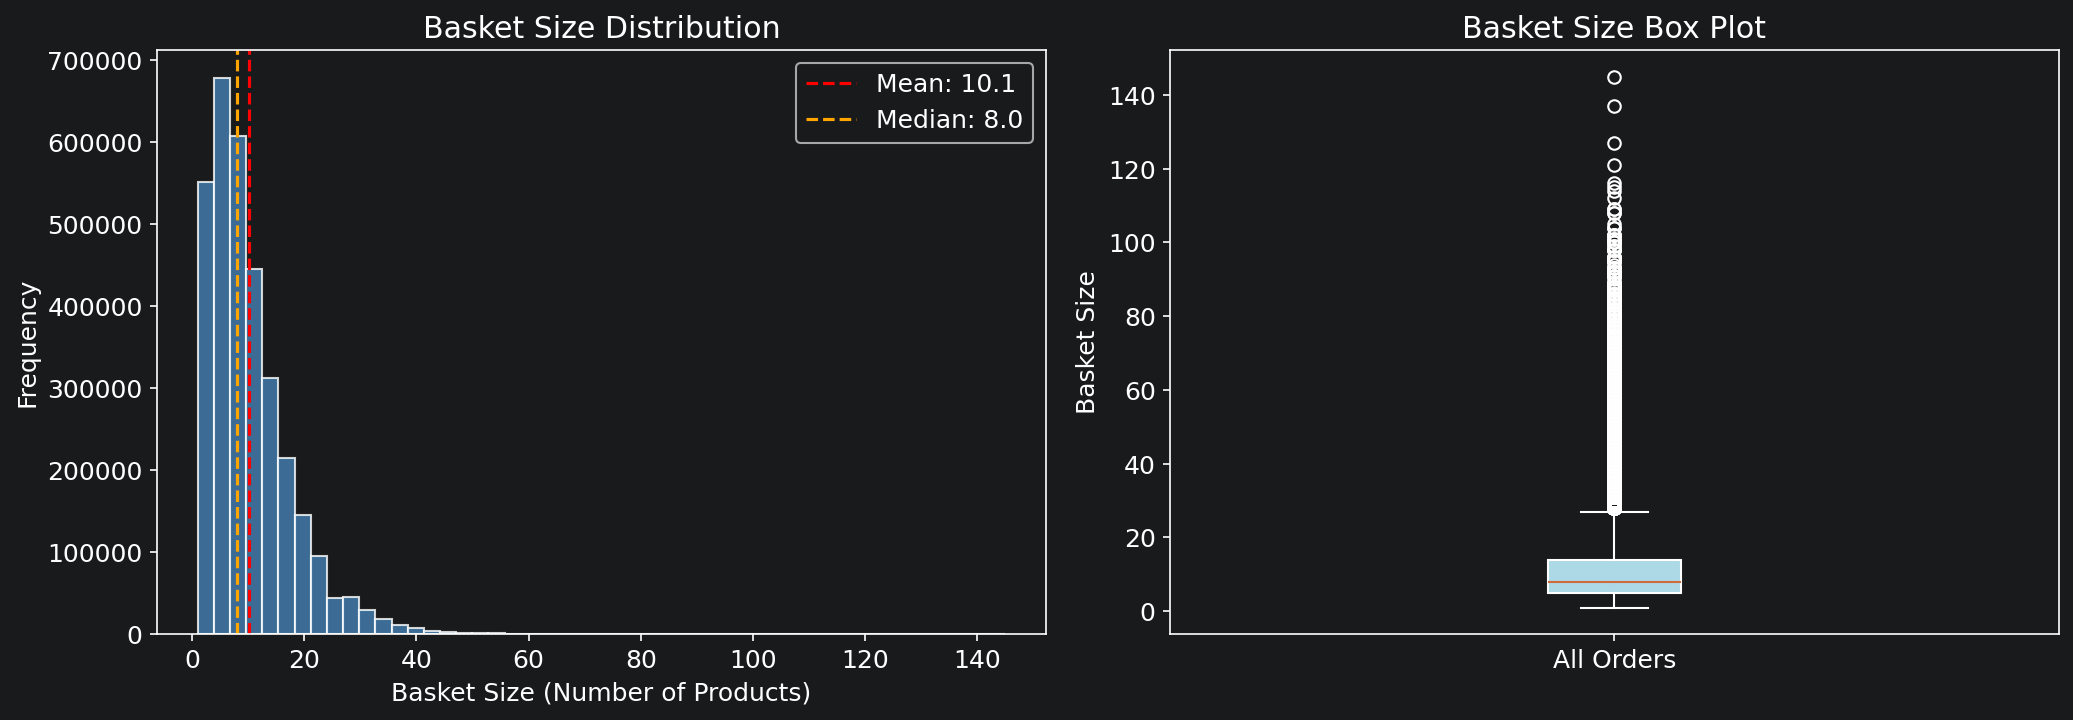

In [12]:
display(Image(filename='plots/basket_size_distribution.png'))

Sipariş Başına Ürün Dağılımı: Yapılan analizde sepet boyutunun ortalama 10.09, medyanın ise 8.00 olduğu görülmüştür. Histogramın right-skewed olması çoğu müşterinin küçük/orta ölçekli alışverişler yaptığını, ancak az sayıda müşterinin 100+ ürüne varan toplu alışverişler gerçekleştirdiğini göstermektedir. Bu dağılım, Apriori algoritmasının karmaşıklığını etkileyen temel faktördür.

##### 1.4.3 Customer activity distribution

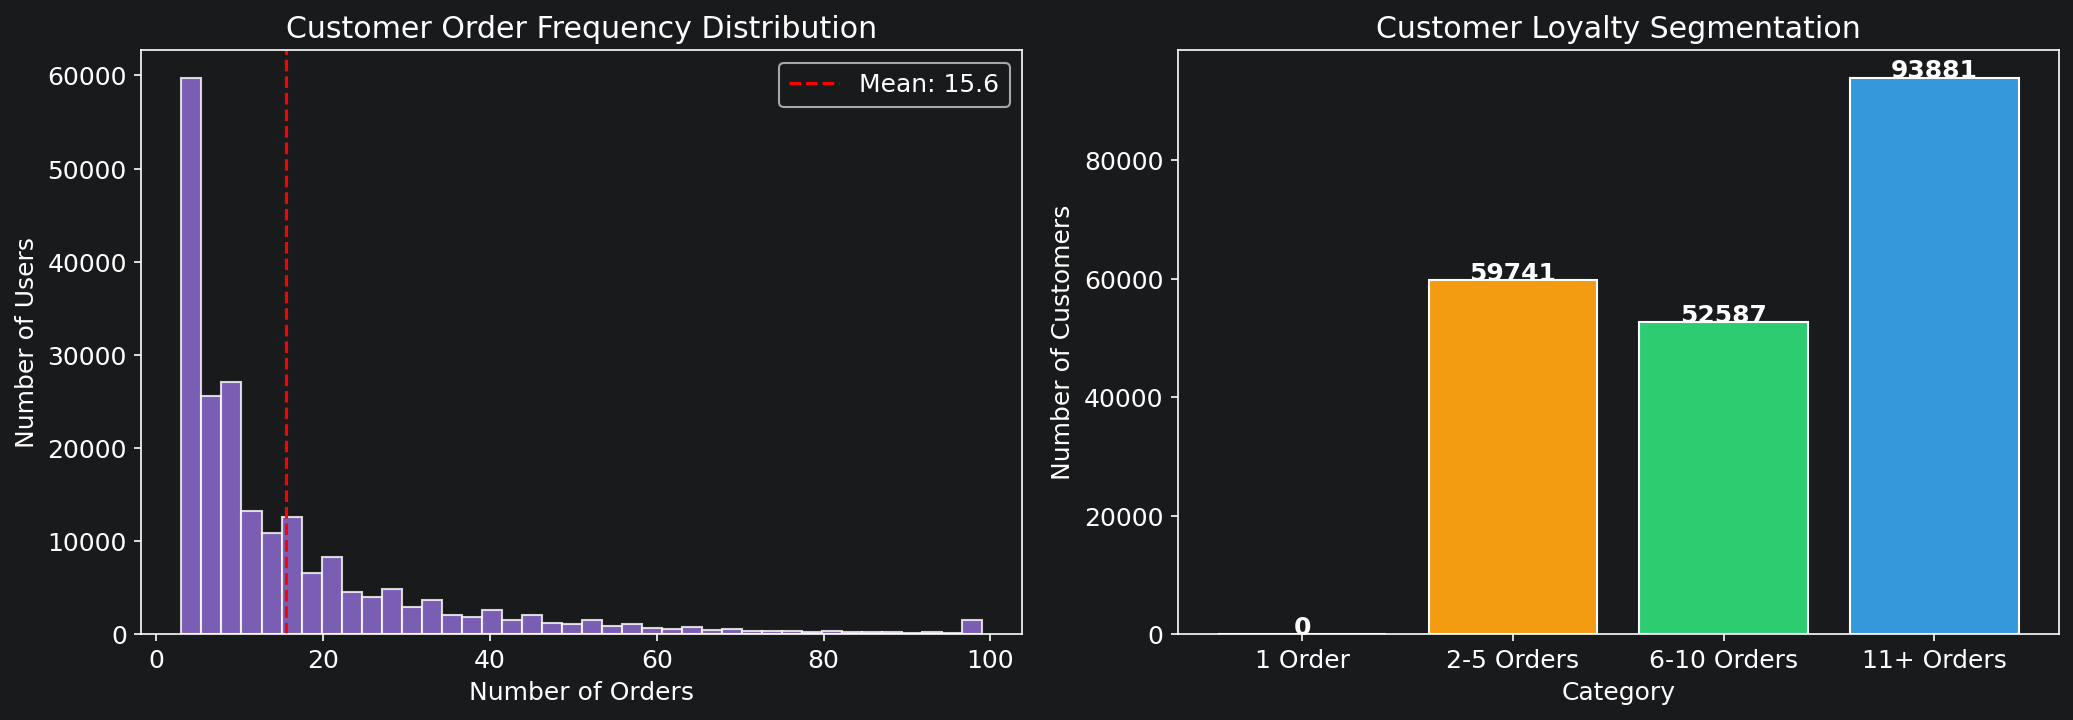

In [13]:
display(Image(filename='plots/customer_activity.png'))

Müşterilerin yaklaşık %75'i "infrequent" kategorisindeyken, geri kalan kesim düzenli alışveriş yapan sadık kitledir. Özellikle 11+ sipariş veren grup, Sequential Pattern Mining (GSP) analizi için en kaliteli veri kaynağını oluşturur; çünkü bu kullanıcıların alışveriş geçmişi, zaman içindeki alışkanlıkları anlamak için yeterli uzunluğa sahiptir.

##### 1.4.4 Time between purchases

--- TIME BETWEEN PURCHASES ---
Mean days:    11.1
Median days:  8.0

Most Frequent Intervals (Top 10):
days_since_prior_order
7.0     3479504
30.0    3070057
6.0     2519939
5.0     2126420
4.0     2080560
8.0     1933815
3.0     1877881
2.0     1464875
9.0     1218973
14.0    1030605
Name: count, dtype: int64


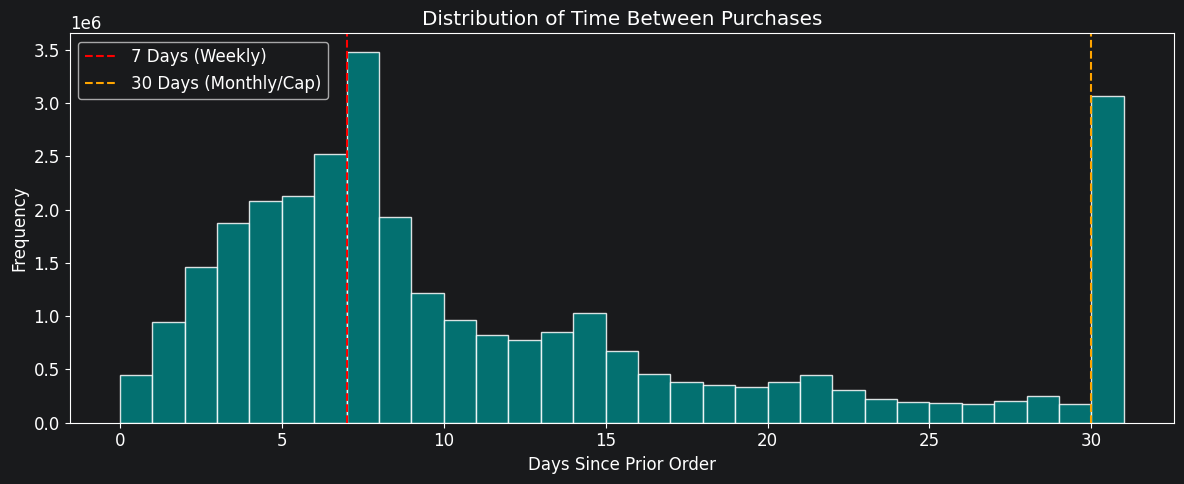

In [14]:
days_data = df_final['days_since_prior_order'].dropna()

print("--- TIME BETWEEN PURCHASES ---")
print(f"Mean days:    {days_data.mean():.1f}")
print(f"Median days:  {days_data.median():.1f}")
print(f"\nMost Frequent Intervals (Top 10):")
print(days_data.value_counts().head(10))

plt.figure(figsize=(12, 5))
# Using 31 bins to represent 0-30 days clearly
plt.hist(days_data, bins=31, range=(0, 31), color='teal', edgecolor='white', alpha=0.85)

# Highlighting the weekly and monthly peaks
plt.axvline(7, color='red', linestyle='--', label='7 Days (Weekly)')
plt.axvline(30, color='orange', linestyle='--', label='30 Days (Monthly/Cap)')

plt.xlabel('Days Since Prior Order')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Purchases')
plt.legend()
plt.tight_layout()

# Save to outputs folder
plt.savefig('plots/days_between_orders.png', dpi=150, bbox_inches='tight')
plt.show()

Alışverişler Arası Süre: Grafik, müşterilerin genellikle haftalık (7 gün) veya aylık (30 gün) periyotlarla alışveriş yapma eğiliminde olduğunu göstermektedir. 30. gündeki yoğunluk, müşterilerin stokları bittiğinde geri döndüğünü kanıtlar. Bu zaman aralığı bilgisi, GSP algoritmasındaki max_gap = 15 kısıtının ne kadar anlamlı olduğunu test etmek için kritik bir referans noktasıdır.

## Part 5
## Scalability and Sampling

In [15]:
TOP_N_PRODUCTS = 5000
USER_SAMPLE_RATE = 0.15
RANDOM_SEED = 42

print("Sampling process started...")

# En popüler ürün ID'lerini belirle (Hata almamak için ID ile işlem yapıyoruz)
top_product_ids = df_final['product_id'].value_counts().head(TOP_N_PRODUCTS).index.tolist()

# Kullanıcı bazlı sampling
unique_users = df_final['user_id'].unique()
sampled_user_ids = np.random.RandomState(RANDOM_SEED).choice(
    unique_users, int(len(unique_users) * USER_SAMPLE_RATE), replace=False
)

# Ana veri setini filtrele
df_sampled = df_final[
    df_final['user_id'].isin(sampled_user_ids) &
    df_final['product_id'].isin(top_product_ids)
].copy()

# 'product_map' kullanarak ID'leri isme çevir
df_sampled['product_name'] = df_sampled['product_id'].map(id_to_name).fillna('product_' + df_sampled['product_id'].astype(str))

df_sampled.to_csv('data/dataset_sampled.csv', index=False, quoting=csv.QUOTE_ALL)

Sampling process started...


In [16]:
print(f"Final Row Count: {len(df_sampled):,}")
print(f"Unique Products: {df_sampled['product_name'].nunique():,}")
print(f"Unique Users: {df_sampled['user_id'].nunique():,}")

Final Row Count: 3,919,479
Unique Products: 4,617
Unique Users: 30,904


##  PART 2
## Association Rule Mining - Apriori & FP-Growth

### 2.1. Grouping Transactions by order_id

In [17]:
print("Creating transactions...")

# Her bir siparişi temsil eden ürün listelerini oluştur
transactions = df_sampled.groupby('order_id')['product_id'].apply(list).tolist()

# Birliktelik kuralı üretebilmek için en az iki ürün içeren Transaction kayıtlarını filtrele
transactions = [t for t in transactions if len(t) >= 2]

print(f"Transactions created. Total: {len(transactions)}")

Creating transactions...
Transactions created. Total: 436859


In [18]:
# Veri setinin son durumunu ve ürün çeşitliliğini kontrol et
print(f"Total transactions: {len(transactions):,}")
print(f"Unique products in transactions: {len(set([i for t in transactions for i in t])):,}")

# Transaction yapısını doğrulamak için ilk kayıttan örnek al
print(f"Sample transaction: {transactions[0][:5]}")

Total transactions: 436,859
Unique products in transactions: 5,000
Sample transaction: ['20392', '27845', '162', '2452', '8575']


In [19]:
# Çok az kural çıkıyorsa -> support'u düşür
# Çok fazla trivial kural çıkıyorsa -> confidence'ı artır

MIN_SUPPORT    = 0.005  # Minimum 0.005 frequency in transactions
MIN_CONFIDENCE = 0.15   # Minimum 15% reliability for the rule
MIN_LIFT       = 1.5    # Lift > 1.0 indicates a significant relationship

print(f"Algorithm Parameters:")
print(f"  Min Support:    {MIN_SUPPORT}")
print(f"  Min Confidence: {MIN_CONFIDENCE}")
print(f"  Min Lift:       {MIN_LIFT}")

# Name mapping yardımcı fonksiyonu
def ids_to_names(id_frozenset):
    return frozenset(id_to_name.get(str(i), id_to_name.get(i, f"product_{i}")) for i in id_frozenset)

Algorithm Parameters:
  Min Support:    0.005
  Min Confidence: 0.15
  Min Lift:       1.5


In [20]:
print(f"df_sampled shape: {df_sampled.shape}")
print(f"Unique products: {df_sampled['product_id'].nunique()}")
print(f"Unique orders: {df_sampled['order_id'].nunique()}")
print(df_sampled['product_id'].value_counts().head(10))

df_sampled shape: (3919479, 5)
Unique products: 5000
Unique orders: 469756
product_id
24852    68535
13176    57005
21137    39760
21903    35928
47209    31356
47766    26032
47626    22409
16797    21375
26209    21043
27845    20672
Name: count, dtype: int64


In [21]:
# One-Hot Encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# RAM tasarrufu sağlamak için veriyi SparseDtype bool yapısına çevir
df_te = pd.DataFrame(te_array, columns=te.columns_).astype(pd.SparseDtype("bool"))

### 2.2. Apriori Algorithm

In [22]:
print("Apriori algorithm execution started...")

# Performans takibi için bellek ve zaman ölçümünü başlat
tracemalloc.start()
start_time = time.time()

# Kombinasyon karmaşıklığını önlemek için max_len ile sık ürün kümelerini hesapla
frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)

# Belirlenen Confidence ve Lift eşiklerine göre Association Rules türet
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules[rules['lift'] >= MIN_LIFT]

# Analiz sonuçlarını yorumlayabilmek için ürün ID değerlerini isimlere dönüştür
rules['antecedents_ids'] = rules['antecedents']
rules['consequents_ids'] = rules['consequents']
rules['antecedents_names'] = rules['antecedents'].apply(ids_to_names)
rules['consequents_names'] = rules['consequents'].apply(ids_to_names)

# Ölçümü sonlandır
runtime = time.time() - start_time
_, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Apriori execution finished in {runtime:.4f} seconds.")

# İlişkisi en yüksek olan ilk 10 kuralı raporla
display(rules[[ 'antecedents_ids', 'antecedents_names', 'consequents_ids', 'consequents_names', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10))

Apriori algorithm execution started...
Apriori execution finished in 65.9695 seconds.


,antecedents_ids,antecedents_names,consequents_ids,consequents_names,support,confidence,lift
78,(31717),(Organic Cilantro),(26209),(Limes),0.005933,0.256202,5.344236
52,(24964),(Organic Garlic),(22935),(Organic Large Extra Fancy Fuji Apple),0.007098,0.192788,5.025738
51,(22935),(Organic Large Extra Fancy Fuji Apple),(24964),(Organic Garlic),0.007098,0.185046,5.025738
79,(26209),(Limes),(47626),(Large Lemon),0.009369,0.195435,3.823792
80,(47626),(Large Lemon),(26209),(Limes),0.009369,0.183312,3.823792
91,"(21137, 13176)","(Bag of Organic Bananas, Organic White Onions)",(47209),(Organic Hass Avocado),0.005091,0.240693,3.369720
85,(5876),(Organic Lemon),(47209),(Organic Hass Avocado),0.007336,0.239251,3.349530
88,(49683),(Cucumber Kirby),(47626),(Large Lemon),0.005247,0.160763,3.145415
83,(30391),(Organic Strawberries),(47209),(Organic Hass Avocado),0.005665,0.208896,2.924564
90,"(21137, 47209)","(Organic Hass Avocado, Organic White Onions)",(13176),(Bag of Organic Bananas),0.005091,0.371285,2.872362


In [23]:
# Sonuçlar
print(f"Rules: {len(rules)}")
print(f"Runtime: {runtime:.4f}s")
print(f"Peak Memory: {peak_mem/1024**2:.2f}MB")

Rules: 76
Runtime: 65.9695s
Peak Memory: 50288.28MB


### 2.3. FP-Growth Algorithm

In [24]:
print("FP-Growth algorithm execution started...")

# Performans kıyaslaması için bellek ve zaman ölçümünü başlat
tracemalloc.start()
start_time = time.time()

# Candidate üretmeden FP-Tree yapısı üzerinden sık ürün kümelerini tespit et
frequent_itemsets_fp = fpgrowth(df_te, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)

# Belirlenen Confidence ve Lift eşiklerine uyan kuralları ayıkla
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules_fp = rules_fp[rules_fp['lift'] >= MIN_LIFT]

# ID değerlerini analiz için anlamlı isimlere dönüştür
rules_fp['antecedents_names'] = rules_fp['antecedents'].apply(ids_to_names)
rules_fp['consequents_names'] = rules_fp['consequents'].apply(ids_to_names)

# Ölçümü sonlandır
fp_runtime = time.time() - start_time
_, fp_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"FP-Growth execution finished in {fp_runtime:.4f} seconds.")

# İlişki gücü en yüksek olan ilk 10 kuralı görüntüle
display(rules_fp[['antecedents_names','consequents_names','support','confidence','lift']].sort_values('lift', ascending=False).head(10))

FP-Growth algorithm execution started...
FP-Growth execution finished in 18.1329 seconds.


,antecedents_names,consequents_names,support,confidence,lift
51,(Organic Cilantro),(Limes),0.005933,0.256202,5.344236
78,(Organic Large Extra Fancy Fuji Apple),(Organic Garlic),0.007098,0.185046,5.025738
79,(Organic Garlic),(Organic Large Extra Fancy Fuji Apple),0.007098,0.192788,5.025738
64,(Limes),(Large Lemon),0.009369,0.195435,3.823792
65,(Large Lemon),(Limes),0.009369,0.183312,3.823792
45,"(Bag of Organic Bananas, Organic White Onions)",(Organic Hass Avocado),0.005091,0.240693,3.369720
15,(Organic Lemon),(Organic Hass Avocado),0.007336,0.239251,3.349530
35,(Cucumber Kirby),(Large Lemon),0.005247,0.160763,3.145415
18,(Organic Strawberries),(Organic Hass Avocado),0.005665,0.208896,2.924564
44,"(Organic Hass Avocado, Organic White Onions)",(Bag of Organic Bananas),0.005091,0.371285,2.872362


In [25]:
# Sonuçlar
print(f"Rules: {len(rules_fp)}")
print(f"Runtime: {fp_runtime:.4f}s")
print(f"Peak Memory: {fp_peak_mem/1024**2:.2f}MB")

Rules: 76
Runtime: 18.1329s
Peak Memory: 2104.52MB


### 2.4. Apriori vs FP-Growth Comparison

In [26]:
print(f"\n{'Metric':<28} {'Apriori':>12} {'FP-Growth':>12}")
print("-" * 54)
comparison_rows = [
    ("Runtime (s)",          runtime,                    fp_runtime),
    ("Peak Memory (MB)",     peak_mem/1024**2,           fp_peak_mem/1024**2),
    ("Frequent Itemsets",    len(frequent_itemsets),     len(frequent_itemsets_fp)),
    ("Rules Generated",      len(rules),                 len(rules_fp)),
    ("Avg Lift",             rules['lift'].mean(),       rules_fp['lift'].mean()),
    ("Max Lift",             rules['lift'].max(),        rules_fp['lift'].max()),
    ("Avg Confidence",       rules['confidence'].mean(), rules_fp['confidence'].mean()),
]
for name, a, fp in comparison_rows:
    print(f"  {name:<26} {a:>12.4f} {fp:>12.4f}")

speedup = runtime / fp_runtime if fp_runtime > 0 else float('inf')
print(f"\nFP-Growth is {speedup:.2f}x faster than Apriori.")
print(f"FP-Growth uses {(peak_mem/1024**2) / (fp_peak_mem/1024**2):.1f}x less memory than Apriori.")


Metric                            Apriori    FP-Growth
------------------------------------------------------
  Runtime (s)                     65.9695      18.1329
  Peak Memory (MB)             50288.2848    2104.5178
  Frequent Itemsets              381.0000     381.0000
  Rules Generated                 76.0000      76.0000
  Avg Lift                         2.3210       2.3210
  Max Lift                         5.3442       5.3442
  Avg Confidence                   0.2240       0.2240

FP-Growth is 3.64x faster than Apriori.
FP-Growth uses 23.9x less memory than Apriori.


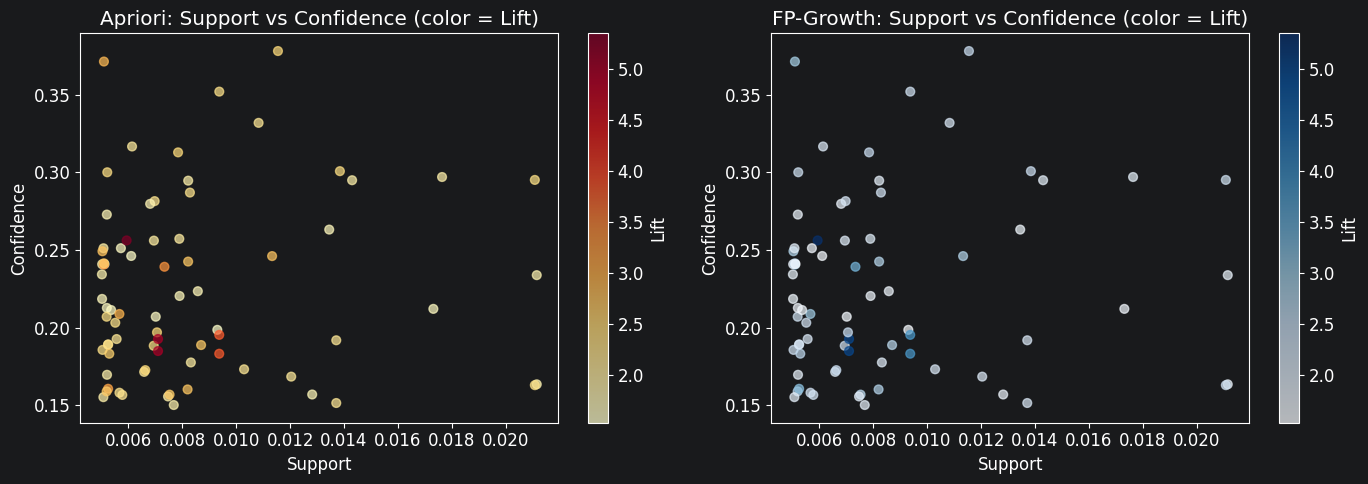

In [27]:
# Scatter plot: Support vs Confidence, colored by Lift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, r, title, cmap in zip(axes,
    [rules, rules_fp], ["Apriori", "FP-Growth"], ["YlOrRd", "Blues"]):
    sc = ax.scatter(r['support'], r['confidence'],
                    c=r['lift'], cmap=cmap, alpha=0.7, s=40)
    plt.colorbar(sc, ax=ax, label='Lift')
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title(f'{title}: Support vs Confidence (color = Lift)')
plt.tight_layout()
plt.savefig('plots/comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5. Avoiding Trivial Patterns

Products such as Banana and Bag of Organic Bananas appear in a large proportion of transactions, producing rules with high support but low lift. These were identified as trivial patterns and excluded from the final rule set to focus on more meaningful associations.

In [28]:
# Analizi domine eden yüksek frekanslı ürün ID'lerini bir kümede topla
dominant_items = {'24852', '13176'}

# Kural içerisinde dominant ürün olup olmadığını kontrol eden fonksiyon
def contains_dominant(id_frozenset):
    return bool(id_frozenset & dominant_items)

# Kuralları filtrele
rules_filtered = rules_fp[
    ~rules_fp['antecedents'].apply(contains_dominant) &
    ~rules_fp['consequents'].apply(contains_dominant)
].copy()

# Filtreleme işlemi sonrası kural sayısındaki değişimi kontrol et
print(f"Rules before filtering: {len(rules_fp)}")
print(f"Rules after removing dominant items: {len(rules_filtered)}")

# Dominant ürünlerden arındırılmış en yüksek Lift değerine sahip kuralları raporla
display(rules_filtered[['antecedents_names','consequents_names','support','confidence','lift']].sort_values('lift', ascending=False).head(10))

Rules before filtering: 76
Rules after removing dominant items: 38


,antecedents_names,consequents_names,support,confidence,lift
51,(Organic Cilantro),(Limes),0.005933,0.256202,5.344236
79,(Organic Garlic),(Organic Large Extra Fancy Fuji Apple),0.007098,0.192788,5.025738
78,(Organic Large Extra Fancy Fuji Apple),(Organic Garlic),0.007098,0.185046,5.025738
64,(Limes),(Large Lemon),0.009369,0.195435,3.823792
65,(Large Lemon),(Limes),0.009369,0.183312,3.823792
15,(Organic Lemon),(Organic Hass Avocado),0.007336,0.239251,3.349530
35,(Cucumber Kirby),(Large Lemon),0.005247,0.160763,3.145415
18,(Organic Strawberries),(Organic Hass Avocado),0.005665,0.208896,2.924564
36,(Organic Whole String Cheese),(Organic White Onions),0.005036,0.249235,2.755706
11,(Organic Raspberries),(Organic White Onions),0.011331,0.246122,2.721280


### 2.6. Saving Rules to Excel

In [29]:
import os
os.makedirs('excel_files', exist_ok=True)

def export_rules(df):
    out = df[['antecedents_names','consequents_names','support','confidence','lift']].copy()
    out['antecedents_names'] = out['antecedents_names'].apply(lambda x: ', '.join(list(x)))
    out['consequents_names'] = out['consequents_names'].apply(lambda x: ', '.join(list(x)))
    return out.sort_values('lift', ascending=False)

apriori_out  = export_rules(rules)
fp_out       = export_rules(rules_fp)
filtered_out = export_rules(rules_filtered)

rules_all = pd.concat([rules, rules_fp], ignore_index=True).drop_duplicates(subset=['antecedents','consequents'])
all_out   = export_rules(rules_all)

# apriori_rules.xlsx
apriori_out.to_excel('excel_files/apriori_rules.xlsx', index=False, engine='openpyxl')
print(f"Saved: apriori_rules.xlsx ({len(apriori_out)} rules)")

# fpgrowth_rules.xlsx
fp_out.to_excel('excel_files/fpgrowth_rules.xlsx', index=False, engine='openpyxl')
print(f"Saved: fpgrowth_rules.xlsx ({len(fp_out)} rules)")

# association_rules.xlsx (Apriori + FP-Growth birleşik)
all_out.to_excel('excel_files/association_rules.xlsx', index=False, engine='openpyxl')
print(f"Saved: association_rules.xlsx ({len(all_out)} rules)")

# filtered_association_rules.xlsx
filtered_out.to_excel('excel_files/filtered_association_rules.xlsx', index=False, engine='openpyxl')
print(f"Saved: filtered_association_rules.xlsx ({len(filtered_out)} rules)")

Saved: apriori_rules.xlsx (76 rules)
Saved: fpgrowth_rules.xlsx (76 rules)
Saved: association_rules.xlsx (76 rules)
Saved: filtered_association_rules.xlsx (38 rules)


## PART 3
## Sequential Pattern Mining (GSP)

### 3.1. Building User Sequences with Temporal Information

In [30]:
user_sequences = {}
print("Building user sequences with temporal info...")

# order_id zamanla ilişkili → sıralama doğru
df_sampled = df_sampled.sort_values(['user_id', 'order_id'])

for (user_id, order_id), group in df_sampled.groupby(['user_id', 'order_id']):

    products = list(set(group['product_id']))  # duplicate temizleme

    days = group['days_since_prior_order'].iloc[0]
    days = 0.0 if pd.isna(days) else float(days)

    if user_id not in user_sequences:
        user_sequences[user_id] = []

    user_sequences[user_id].append((order_id, days, products))


print(f"Total users with sequences: {len(user_sequences):,}")

# kontrol
sample_user = list(user_sequences.keys())[0]
print(f"\nSample (User {sample_user}, first 3 orders):")

for ord_id, d, prods in user_sequences[sample_user][:3]:
    print(f"  order_id={ord_id}, days={d}, products={prods[:3]}")

Building user sequences with temporal info...
Total users with sequences: 30,904

Sample (User 4, first 3 orders):
  order_id=94891, days=15.0, products=['25146']
  order_id=691089, days=21.0, products=['17769', '11865', '19057']
  order_id=2557754, days=0.0, products=['25623', '21573', '26576']


### 3.2. GSP Algorithm

In [31]:
def run_gsp(user_sequences, min_support=0.02, max_gap=15):
    print(f"Running GSP | max_gap={max_gap} | min_support={min_support}")
    t_start = time.time()

    N = len(user_sequences)

    # --- Frequent 1-Sequences ---
    item_count = defaultdict(int)

    for orders in user_sequences.values():
        seen = set()
        for _, _, products in orders:
            for item in products:
                if item not in seen:
                    item_count[item] += 1
                    seen.add(item)

    freq_1 = {
        item: count / N
        for item, count in item_count.items()
        if count / N >= min_support
    }

    print(f"  Frequent 1-sequences: {len(freq_1):,}")

    # --- pre-filter ---
    freq_1_set = set(freq_1.keys())

    filtered_orders = {}
    for user_id, orders in user_sequences.items():
        filtered_orders[user_id] = [
            (ord_id, days, [item for item in products if item in freq_1_set])
            for (ord_id, days, products) in orders
        ]

    # --- Frequent 2-Sequences (PAIRWISE GAP) ---
    pair_count = defaultdict(int)

    for orders in filtered_orders.values():
        seen_pairs = set()

        for i in range(len(orders)):
            items_a = orders[i][2]
            if not items_a:
                continue

            for j in range(i + 1, len(orders)):
                gap_ab = orders[j][1]

                if gap_ab > max_gap:
                    break

                items_b = orders[j][2]
                if not items_b:
                    continue

                for a in items_a:
                    for b in items_b:
                        pair = (a, b)
                        if pair not in seen_pairs:
                            pair_count[pair] += 1
                            seen_pairs.add(pair)

    freq_2 = {
        pair: count / N
        for pair, count in pair_count.items()
        if count / N >= min_support
    }

    print(f"  Frequent 2-sequences: {len(freq_2):,}")

    runtime = time.time() - t_start
    print(f"  Runtime: {runtime:.2f}s")

    return freq_1, freq_2, runtime

### 3.3. GSP with Different max_gap Values

In [32]:
results = {}

for max_gap in [5, 15, 30]:
    freq_1, freq_2, runtime = run_gsp(
        user_sequences,
        min_support=0.01,
        max_gap=max_gap
    )

    results[max_gap] = {
        'freq_1': freq_1,
        'freq_2': freq_2,
        'runtime': runtime
    }

    print()

Running GSP | max_gap=5 | min_support=0.01
  Frequent 1-sequences: 1,133
  Frequent 2-sequences: 619
  Runtime: 5.41s

Running GSP | max_gap=15 | min_support=0.01
  Frequent 1-sequences: 1,133
  Frequent 2-sequences: 4,928
  Runtime: 18.93s

Running GSP | max_gap=30 | min_support=0.01
  Frequent 1-sequences: 1,133
  Frequent 2-sequences: 11,470
  Runtime: 32.94s



### 3.5. Displaying Results for max_gap=15 (Main Experiment)

In [33]:
freq_1_15 = results[15]['freq_1']
freq_2_15 = results[15]['freq_2']

# --- Top 1 ---
print("Top 10 Frequent 1-sequences (max_gap=15):")
top_1 = sorted(freq_1_15.items(), key=lambda x: x[1], reverse=True)[:10]

for item, sup in top_1:
    name = id_to_name.get(item, id_to_name.get(str(item), f'product_{item}'))
    print(f"  {name:<50} support={sup:.4f}")


# --- Top 2 ---
print("\nTop 10 Frequent 2-sequences (max_gap=15):")
top_2 = sorted(freq_2_15.items(), key=lambda x: x[1], reverse=True)[:10]

for (a, b), sup in top_2:
    name_a = id_to_name.get(a, id_to_name.get(str(a), f'product_{a}'))
    name_b = id_to_name.get(b, id_to_name.get(str(b), f'product_{b}'))
    print(f"  {name_a:<40} -> {name_b:<40} support={sup:.4f}")

Top 10 Frequent 1-sequences (max_gap=15):
  Banana                                             support=0.3535
  Bag of Organic Bananas                             support=0.3114
  Organic White Onions                               support=0.2855
  Organic Baby Spinach                               support=0.2656
  Large Lemon                                        support=0.2240
  Limes                                              support=0.2186
  Organic Hass Avocado                               support=0.2085
  Organic Avocado                                    support=0.2077
  Strawberries                                       support=0.2053
  Organic Blueberries                                support=0.1812

Top 10 Frequent 2-sequences (max_gap=15):
  Banana                                   -> Banana                                   support=0.2038
  Bag of Organic Bananas                   -> Bag of Organic Bananas                   support=0.1706
  Organic White Onions         

### 3.6. max_gap Comparison Visualization

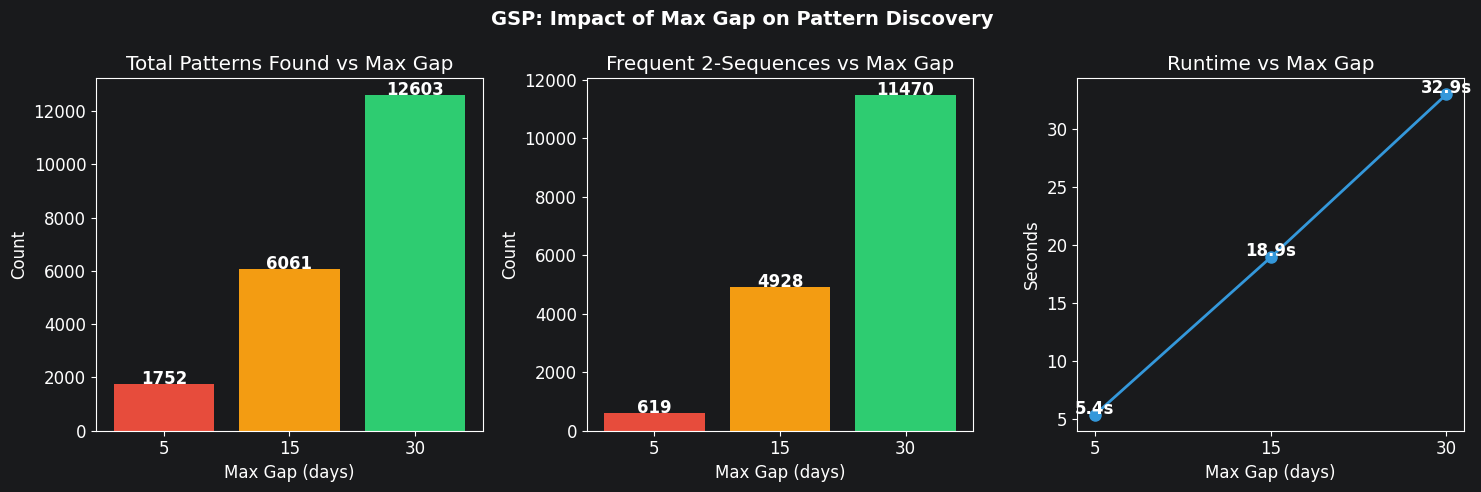

Saved: gsp_max_gap_comparison.png


In [34]:
gap_values = list(results.keys())
n_freq_1   = [len(results[g]['freq_1']) for g in gap_values]
n_freq_2   = [len(results[g]['freq_2']) for g in gap_values]
runtimes   = [results[g]['runtime']     for g in gap_values]
n_total    = [n_freq_1[i] + n_freq_2[i] for i in range(len(gap_values))]
colors     = ['#e74c3c', '#f39c12', '#2ecc71']
x          = [str(g) for g in gap_values]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(x, n_total, color=colors)
axes[0].set_title('Total Patterns Found vs Max Gap')
axes[0].set_xlabel('Max Gap (days)')
axes[0].set_ylabel('Count')
for i, v in enumerate(n_total):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].bar(x, n_freq_2, color=colors)
axes[1].set_title('Frequent 2-Sequences vs Max Gap')
axes[1].set_xlabel('Max Gap (days)')
axes[1].set_ylabel('Count')
for i, v in enumerate(n_freq_2):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[2].plot(x, runtimes, marker='o', color='#3498db', linewidth=2, markersize=8)
axes[2].set_title('Runtime vs Max Gap')
axes[2].set_xlabel('Max Gap (days)')
axes[2].set_ylabel('Seconds')
for i, v in enumerate(runtimes):
    axes[2].text(i, v + 0.1, f'{v:.1f}s', ha='center', fontweight='bold')

plt.suptitle('GSP: Impact of Max Gap on Pattern Discovery', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gsp_max_gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gsp_max_gap_comparison.png")

## 3.6. Avoiding Trivial Patterns & Saving Patterns to Excel

In [35]:
output_dir = 'excel_files'
os.makedirs(output_dir, exist_ok=True)

dominant_items = {'24852', '13176'}

for gap in [5, 15, 30]:

    # --- df_f1 ---
    f1_data = results[gap]['freq_1']
    df_f1 = pd.DataFrame([
        {
            'product_id': pid,
            'product_name': id_to_name.get(pid, id_to_name.get(str(pid), f'Unknown_{pid}')),
            'support': sup
        }
        for pid, sup in sorted(f1_data.items(), key=lambda x: x[1], reverse=True)
    ])

    df_f1.to_excel(os.path.join(output_dir, f'gsp_gap{gap}_1sequences.xlsx'), index=False)
    print(f"Saved: gap{gap}_1sequences")


    # --- df_f2 RAW ---
    f2_data = results[gap]['freq_2']
    df_f2_raw = pd.DataFrame([
        {
            'antecedent_id': a,
            'antecedent_name': id_to_name.get(a, id_to_name.get(str(a), f'product_{a}')),
            'consequent_id': b,
            'consequent_name': id_to_name.get(b, id_to_name.get(str(b), f'product_{b}')),
            'support': sup
        }
        for (a, b), sup in sorted(f2_data.items(), key=lambda x: x[1], reverse=True)
    ])

    df_f2_raw.to_excel(os.path.join(output_dir, f'gsp_gap{gap}_2sequences_raw.xlsx'), index=False)
    print(f"Saved: gap{gap}_2sequences_raw")


    # --- df_f2 FILTERED ---
    # Koşul 1: Antecedent ve Consequent aynı olmamalı
    # Koşul 2 & 3: Ne antecedent ne de consequent dominant_items listesinde olmamalı
    df_f2_filtered = df_f2_raw[
        (df_f2_raw['antecedent_id'] != df_f2_raw['consequent_id']) &
        (~df_f2_raw['antecedent_id'].astype(str).isin(dominant_items)) &
        (~df_f2_raw['consequent_id'].astype(str).isin(dominant_items))
    ].copy()

    df_f2_filtered.to_excel(os.path.join(output_dir, f'gsp_gap{gap}_2sequences_filtered.xlsx'), index=False)
    print(f"Saved: gap{gap}_2sequences_filtered")

Saved: gap5_1sequences
Saved: gap5_2sequences_raw
Saved: gap5_2sequences_filtered
Saved: gap15_1sequences
Saved: gap15_2sequences_raw
Saved: gap15_2sequences_filtered
Saved: gap30_1sequences
Saved: gap30_2sequences_raw
Saved: gap30_2sequences_filtered


## PART 4
 ## Recommendation System

In [36]:
# Ürün isimlerinden ilgili tüm ID değerlerine erişmek için Reverse Mapping
name_to_ids = defaultdict(set)
for pid, name in id_to_name.items():
    name_to_ids[name].add(pid)

print("Organic Hass Avocado ids:", name_to_ids['Organic Hass Avocado'])
print("Bag of Organic Bananas ids:", name_to_ids['Bag of Organic Bananas'])
print("Organic Baby Spinach ids:", name_to_ids['Organic Baby Spinach'])

Organic Hass Avocado ids: {'42606', '39144', '17821', '25339', '21914', '46430', '27998', '20247', '31040', '34975', '6006', '47972', '35503', '35512', '18111', '38806', '32225', '47209', '7640'}
Bag of Organic Bananas ids: {'27509', '46580', '11444', '24369', '2497', '37137', '4190', '28145', '34694', '10541', '41788', '13801', '4783', '9146', '6095', '29222', '8357', '13176', '20733', '19626', '46490', '42241', '15914', '41257', '2577', '28207'}
Organic Baby Spinach ids: {'36676', '21903', '23671', '13754', '17175', '11767', '40909', '21429', '47355', '15578', '31035', '22457', '7338', '20827'}


### 4.1. Unknown User  -  FP-Growth based recommendation

In [37]:
def recommend_unknown_user(basket_names, rules_df, id_to_name, top_n=5):
    # İsimlerden ID değerlerine erişmek için mapping kur
    name_to_ids = defaultdict(set)
    for pid, name in id_to_name.items():
        name_to_ids[name].add(pid)

    # Basket içindeki ürün isimlerini sistemdeki ID karşılıklarıyla eşleştir
    basket_ids = set()
    for name in basket_names:
        basket_ids.update(name_to_ids.get(name, set()))

    recommendations = {}
    for _, rule in rules_df.iterrows():
        antecedents = set(rule['antecedents'])
        consequents = set(rule['consequents'])

        # Rule koşulu sepette varsa ve önerilen ürün sepette yoksa süreci başlat
        if antecedents.issubset(basket_ids) and not consequents.issubset(basket_ids):
            for item in consequents:
                if item not in basket_ids:
                    # Aynı ürünü öneren farklı Rule kayıtları arasından en yüksek Lift değerine sahip olanı seç
                    if item not in recommendations or recommendations[item]['lift'] < rule['lift']:
                        recommendations[item] = {
                            'lift':       rule['lift'],
                            'confidence': rule['confidence'],
                            'support':    rule['support']
                        }

    # Recommendation listesini Lift gücüne göre azalan sırada diz (top n)
    sorted_recs = sorted(recommendations.items(), key=lambda x: x[1]['lift'], reverse=True)[:top_n]
    return [
        {
            'product_id':   item,
            'product_name': id_to_name.get(str(item), f'product_{item}'),
            'lift':         m['lift'],
            'confidence':   m['confidence'],
            'support':      m['support']
        }
        for item, m in sorted_recs
    ]

In [38]:
# Test: Unknown User
test_baskets = [
    ['Organic Hass Avocado', 'Bag of Organic Bananas', 'Organic Baby Spinach'],
    ['Limes', 'Large Lemon', 'Organic Cilantro'],
    ['Organic Whole Milk', 'Organic Strawberries'],
    ['Cucumber Kirby', 'Organic Garlic'],
    ['Organic Blueberries', 'Organic Raspberries']
]

all_recs = []
for basket in test_baskets:
    recs = recommend_unknown_user(basket, rules_fp, id_to_name, top_n=5)
    for r in recs:
        all_recs.append({
            'input_basket': ', '.join(basket),
            'recommended_product': r['product_name'],
            'lift': r['lift'],
            'confidence': r['confidence'],
            'support': r['support']
        })

    print(f"Basket: {basket}")
    if recs:
        for i, r in enumerate(recs, 1):
            print(f"  {i}. {r['product_name']} (Lift={r['lift']:.4f})")
    else:
        print("  No recommendations found.")
    print()

Basket: ['Organic Hass Avocado', 'Bag of Organic Bananas', 'Organic Baby Spinach']
  1. Organic White Onions (Lift=2.6702)

Basket: ['Limes', 'Large Lemon', 'Organic Cilantro']
  1. Organic Avocado (Lift=2.6999)
  2. Organic Baby Spinach (Lift=1.9091)
  3. Banana (Lift=1.6899)

Basket: ['Organic Whole Milk', 'Organic Strawberries']
  1. Organic Hass Avocado (Lift=2.9246)
  2. Organic Baby Spinach (Lift=2.2763)
  3. Organic White Onions (Lift=2.2472)
  4. Bag of Organic Bananas (Lift=1.9811)

Basket: ['Cucumber Kirby', 'Organic Garlic']
  1. Organic Large Extra Fancy Fuji Apple (Lift=5.0257)
  2. Large Lemon (Lift=3.1454)
  3. Organic Avocado (Lift=2.6788)
  4. Organic Baby Spinach (Lift=2.3090)
  5. Organic Hass Avocado (Lift=2.1951)

Basket: ['Organic Blueberries', 'Organic Raspberries']
  1. Organic White Onions (Lift=2.7213)
  2. Organic Hass Avocado (Lift=2.6445)
  3. Bag of Organic Bananas (Lift=2.3268)



In [39]:
df_unknown_recs = pd.DataFrame(all_recs)
df_unknown_recs.to_excel('excel_files/recommendations_unknown_user.xlsx', index=False, engine='openpyxl')
print(f"Saved: recommendations_unknown_user.xlsx ({len(df_unknown_recs)} recommendations)")

Saved: recommendations_unknown_user.xlsx (16 recommendations)


### 4.2. Known User  -  GSP-based recommendation

In [40]:
def recommend_known_user(user_id, basket_names, user_sequences, freq_2, id_to_name, top_n=5):
    name_to_ids = defaultdict(set)
    for pid, name in id_to_name.items():
        name_to_ids[name].add(pid)

    basket_ids = set()
    for name in basket_names:
        basket_ids.update(name_to_ids.get(name, set()))

    # Müşterinin geçmiş sequence verisinden tüm satın aldığı ürünleri topla
    past_ids = set()
    if user_id in user_sequences:
        for _, _, products in user_sequences[user_id]:
            past_ids.update(products)

    recommendations = {}
    # GSP sonuçlarındaki (A -> B) artarda olan paternleri kullanarak öneri üret
    for (item_a, item_b), support in freq_2.items():
        # Mevcut Basket veya geçmiş alışkanlıklarla eşleşen paternleri filtrele
        if (item_a in basket_ids or item_a in past_ids) and item_b not in basket_ids:
            # Aynı ürün için farklı paternler varsa en yüksek Support değerini baz al
            if item_b not in recommendations or recommendations[item_b] < support:
                recommendations[item_b] = support

    # Önerileri Support değerine göre azalan sırada diz (top n)
    sorted_recs = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [
        {
            'product_id':   item,
            'product_name': id_to_name.get(str(item), f'product_{item}'),
            'support':      sup
        }
        for item, sup in sorted_recs
    ]

In [41]:
# Test: Known User
test_users = list(user_sequences.keys())[:5]  # ilk 5 kullanıcı
test_basket_known = ['Organic Hass Avocado', 'Organic Baby Spinach']

all_known_recs = []
for uid in test_users:
    recs = recommend_known_user(uid, test_basket_known, user_sequences, freq_2_15, id_to_name, top_n=5)
    for r in recs:
        all_known_recs.append({
            'user_id': uid,
            'input_basket': ', '.join(test_basket_known),
            'recommended_product': r['product_name'],
            'support': r['support']
        })
    print(f"User {uid}:")
    if recs:
        for i, r in enumerate(recs, 1):
            print(f"  {i}. {r['product_name']} (Support={r['support']:.4f})")
    else:
        print("  No recommendations found.")
    print()

df_known_recs = pd.DataFrame(all_known_recs)
df_known_recs.to_excel('excel_files/recommendations_known_user.xlsx', index=False, engine='openpyxl')
print(f"Saved: recommendations_known_user.xlsx ({len(df_known_recs)} recommendations)")

User 4:
  1. Bag of Organic Bananas (Support=0.0821)
  2. Organic White Onions (Support=0.0801)
  3. Banana (Support=0.0751)
  4. Organic Avocado (Support=0.0605)
  5. Limes (Support=0.0554)

User 9:
  1. Bag of Organic Bananas (Support=0.0821)
  2. Organic White Onions (Support=0.0801)
  3. Banana (Support=0.0751)
  4. Organic Raspberries (Support=0.0681)
  5. Organic Avocado (Support=0.0605)

User 11:
  1. Bag of Organic Bananas (Support=0.1706)
  2. Organic White Onions (Support=0.0922)
  3. Limes (Support=0.0821)
  4. Banana (Support=0.0751)
  5. Organic Avocado (Support=0.0605)

User 17:
  1. Bag of Organic Bananas (Support=0.0821)
  2. Organic White Onions (Support=0.0801)
  3. Strawberries (Support=0.0797)
  4. Banana (Support=0.0751)
  5. Organic Avocado (Support=0.0605)

User 26:
  1. Bag of Organic Bananas (Support=0.0821)
  2. Organic White Onions (Support=0.0801)
  3. Banana (Support=0.0751)
  4. Organic Avocado (Support=0.0605)
  5. Limes (Support=0.0554)

Saved: recommend

In [42]:
df_known_recs = pd.DataFrame(all_known_recs)
df_known_recs.to_excel('excel_files/recommendations_known_user.xlsx', index=False, engine='openpyxl')
print(f"Saved: recommendations_known_user.xlsx ({len(df_known_recs)} recommendations)")

Saved: recommendations_known_user.xlsx (25 recommendations)
